In [ ]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

DATA_PATH = r"D:\DATA\all_stock_data_ts_20140102_20251231.csv"
MARKET_VALUE_DIR = r"D:\DATA\MARKET_VALUE"


In [ ]:
OUTPUT_DIR = r"D:\DATA\Barra"

# Test reading market value feather
f = os.listdir(MARKET_VALUE_DIR)[0]
df = pd.read_feather(os.path.join(MARKET_VALUE_DIR, f))
print(df.columns)


In [2]:
import pandas as pd
import numpy as np


In [3]:
all_stock_data_path = r"DATA\all_stock_data_ts_20140102_20251231.csv"
all_stock_data = pd.read_csv(all_stock_data_path)

In [4]:
all_stock_data.head()

,date,code,open,high,low,close,volume,amount
0,2014-01-02,1,5.26,5.34,5.23,5.31,48991089.0,596223744.4
1,2014-01-03,1,5.27,5.28,5.11,5.18,55111484.0,656631302.4
2,2014-01-06,1,5.16,5.21,4.99,5.06,58211823.0,679280389.7
3,2014-01-07,1,5.00,5.10,4.99,5.05,33840749.0,393977581.0
4,2014-01-08,1,5.05,5.18,5.00,5.10,45776816.0,538436179.5


In [ ]:
def calculate_index_smoothness(stock_data, codes, start_date, end_date):
    codes = [int(code) for code in codes]
    stock_data = stock_data[stock_data['code'].isin(codes)]
    stock_data = stock_data[(stock_data['date'] >= start_date) & (stock_data['date'] <= end_date)]
    
    if stock_data.empty:
        return np.nan
        
    # 计算每日收益率
    # pivot 后取均值得到等权指数收益率
    price_df = stock_data.pivot(index='date', columns='code', values='close')
    if price_df.empty or len(price_df) < 2:
        return np.nan
        
    index_r = price_df.pct_change().dropna().mean(axis=1)
    
    # 检查分母是否为 0 或 index_r 是否为空
    denom = index_r.iloc[1:].abs().sum()
    if denom == 0 or np.isnan(denom):
        return np.nan
        
    # 计算指数平滑度
    smooth = index_r.sum() / denom
    
    return smooth

In [28]:
codes = ['000667', '000671', '000888', '002033','002059', '002081', '002305','300197', '600138', '600340', '600606']
smooth = calculate_index_smoothness(all_stock_data, codes, '2022-03-15', '2022-03-31')
print("指数平滑度: ", smooth)


指数平滑度:  0.9208098983243217


In [27]:
codes = ['000002', '000069', '000667', '000671', '000888', '002033', '002081', '002305','300197', '600138', '600340', '600606']
smooth = calculate_index_smoothness(all_stock_data, codes, '2022-03-15', '2022-03-31')
print("指数平滑度: ", smooth)


指数平滑度:  0.9163631236179214


In [21]:
GX_con_path = r"DATA\GX_HOTSPOT\【国信金工】强势概念及股票池明细.xlsx"
GX_con_detail = pd.read_excel(GX_con_path, sheet_name='强势概念明细')
GX_con_pool = pd.read_excel(GX_con_path, sheet_name='强势概念股票池')
output_path = r"DATA\GX_HOTSPOT\sommth_recal.xlsx"

In [23]:
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    GX_con_detail.to_excel(writer, sheet_name='强势概念明细', index=False)
    GX_con_pool.to_excel(writer, sheet_name='强势概念股票池', index=False)

print(f"计算完成并保存至: {output_path}")

计算完成并保存至: DATA\GX_HOTSPOT\sommth_recal.xlsx


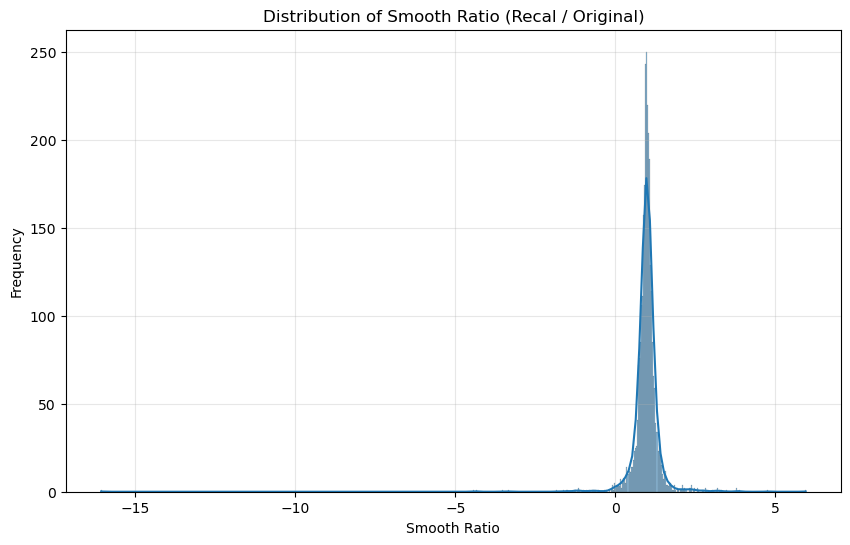

每日平均比例汇总已成功保存至: DATA\GX_HOTSPOT\smooth_ratio_summary.xlsx
         date  average_smooth_ratio
0  2018-02-28              1.144567
1  2018-03-30              1.073650
2  2018-04-27              0.638055
3  2018-07-31              0.829802
4  2018-08-31              0.556146


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 计算 smooth_recal 与原始 Smooth 的比例
# 假设 smooth_recal 是最后生成的列，Smooth 是原始表格中的列
GX_con_detail['smooth_ratio'] = GX_con_detail['smooth_recal'] / GX_con_detail['Smooth']

# 2. 绘制比例分布图
plt.figure(figsize=(10, 6))
sns.histplot(GX_con_detail['smooth_ratio'].dropna(), kde=True)
plt.title('Distribution of Smooth Ratio (Recal / Original)')
plt.xlabel('Smooth Ratio')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

# 3. 统一日期格式并按结束日期（当前日期）求比例平均值
GX_con_detail['formatted_end_date'] = GX_con_detail['当前日期'].apply(format_date)
daily_avg_ratio = GX_con_detail.groupby('formatted_end_date')['smooth_ratio'].mean().reset_index()
daily_avg_ratio.columns = ['date', 'average_smooth_ratio']

# 4. 保存汇总结果为新的 Excel 文件
summary_output_path = r"DATA\GX_HOTSPOT\smooth_ratio_summary.xlsx"
daily_avg_ratio.to_excel(summary_output_path, index=False)

print(f"每日平均比例汇总已成功保存至: {summary_output_path}")
print(daily_avg_ratio.head())

In [2]:
import pandas as pd
import numpy as np
import os
from core.NavAnalyzer import NAVAnalyzer, Visualizer

def load_data():
    # 1. 加载中证全指 (000985.CSI.xlsx)
    csi_path = r"D:\DATA\INDEX\STOCK\000985.CSI.xlsx"
    df_csi = pd.read_excel(csi_path, header=5)
       
    if 'Date' not in df_csi.columns:
        # 如果 'Date' 不在列中，可能在 index 中或者列名略有不同
        df_csi = pd.read_excel(csi_path, header=5)
    
    df_csi['Date'] = pd.to_datetime(df_csi['Date'])
    df_csi = df_csi.set_index('Date').sort_index()
    csi_nav = df_csi['close']
    csi_nav.name = "中证全指"

    # 2. 加载中信一级行业 (ZX_YJHY.csv)
    zx_path = r"D:\DATA\INDEX\ZX\ZX_EJHY.csv"
    # 跳过元数据行
    df_zx = pd.read_csv(zx_path, encoding='gbk', skiprows=10)
    
    # 过滤掉非日期行
    # pd.to_datetime 使用 errors='coerce' 会将无法解析的行变为 NaT
    df_zx.iloc[:, 0] = pd.to_datetime(df_zx.iloc[:, 0], errors='coerce')
    df_zx = df_zx.dropna(subset=[df_zx.columns[0]])
    
    df_zx = df_zx.set_index(df_zx.columns[0]).sort_index()
    # 转为数值型
    df_zx = df_zx.apply(pd.to_numeric, errors='coerce')
    # 计算算术平均作为行业基准净值
    zx_mean_nav = df_zx.mean(axis=1)
    zx_mean_nav.name = "中信一级行业算数平均"

    return csi_nav, zx_mean_nav

def compare_navs():
    csi_nav, zx_mean_nav = load_data()
    
    # 对齐日期 (求交集)
    common_idx = csi_nav.index.intersection(zx_mean_nav.index)
    csi_nav = csi_nav.loc[common_idx]
    zx_mean_nav = zx_mean_nav.loc[common_idx]
    
    # 归一化 (以起始点为1)
    csi_norm = csi_nav / csi_nav.iloc[0]
    zx_norm = zx_mean_nav / zx_mean_nav.iloc[0]
    
    # 计算收益率用于性能分析
    csi_ret = csi_norm.pct_change().fillna(0)
    zx_ret = zx_norm.pct_change().fillna(0)
    
    # 使用 NAVAnalyzer 进行分析
    analyzer_csi = NAVAnalyzer(csi_ret, name="中证全指")
    analyzer_zx = NAVAnalyzer(zx_ret, name="中信一级行业算数平均")
    
    stats_csi = analyzer_csi.compute_stats()
    stats_zx = analyzer_zx.compute_stats()
    
    print("\n--- 绩效对比统计 ---")
    print(f"{'指标':<20} | {'中证全指':<15} | {'中信一级行业':<15}")
    print("-" * 55)
    for key in ['annual_return', 'annual_volatility', 'sharpe_ratio', 'max_drawdown']:
        val_csi = stats_csi[key]
        val_zx = stats_zx[key]
        if "ratio" in key:
            fmt = ".2f"
            suffix = ""
        else:
            fmt = ".2f"
            suffix = "%"
        print(f"{key:<20} | {val_csi:{fmt}}{suffix} | {val_zx:{fmt}}{suffix}")
    
    # 绘图对比
    output_dir = "results/nav_comparison"
    os.makedirs(output_dir, exist_ok=True)
    
    nav_dict = {
        "中证全指": csi_norm,
        "中信一级行业算数平均": zx_norm
    }
    
    # 1. 净值曲线对比
    from core.NavAnalyzer import PerformanceReport
    PerformanceReport.compare_multiple_navs(nav_dict, output_dir, title="Net Value Comparison: CSI 000985 vs CITIC Ind Mean")
    
    # 2. 回撤曲线对比
    Visualizer.plot_drawdown_curve(nav_dict, output_dir, filename="comparison_drawdown.png")
    
    print(f"\n对比图表已保存至: {output_dir}")

if __name__ == "__main__":
    compare_navs()


TypeError: Invalid value '0      2026-03-03
1      2026-03-02
2      2026-02-27
3      2026-02-26
4      2026-02-25
          ...    
5134   2005-01-06
5135   2005-01-05
5136   2005-01-04
5137   2004-12-31
5138          NaT
Name: 2026/3/4, Length: 5139, dtype: datetime64[us]' for dtype 'str'

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from core.NavAnalyzer import NAVAnalyzer, Visualizer, PerformanceReport

def compare_yjhy_with_csi985():
    # 1. 加载中证全指 (000985)
    csi_path = r"D:\DATA\INDEX\STOCK\000985.CSI.xlsx"
    df_csi = pd.read_excel(csi_path, header=5)
    df_csi['Date'] = pd.to_datetime(df_csi['Date'])
    df_csi = df_csi.set_index('Date').sort_index()
    csi_nav = df_csi['close']
    csi_nav.name = "中证全指(000985)"

    # 2. 加载中信一级行业价格数据 (yjhy_prices.csv)
    yjhy_path = r"D:\DATA\INDEX\ZX\yjhy_prices.csv"
    # 尝试使用 utf-8 编码，通常包含中文字符的文件如果不符合 GBK，可能是 UTF-8
    try:
        df_yjhy = pd.read_csv(yjhy_path, encoding='utf-8')
    except UnicodeDecodeError:
        # 如果 utf-8 也失败，尝试 utf-8-sig (处理带有 BOM 的文件)
        df_yjhy = pd.read_csv(yjhy_path, encoding='utf-8-sig')
        
    df_yjhy['TradingDay'] = pd.to_datetime(df_yjhy['TradingDay'])
    df_yjhy = df_yjhy.set_index('TradingDay').sort_index()
    
    # 确保所有列都是数值型
    df_yjhy = df_yjhy.apply(pd.to_numeric, errors='coerce')
    
    # 计算列等权平均 (每日收益率的平均)
    yjhy_ret_df = df_yjhy.pct_change().dropna()
    yjhy_equal_weight_ret = yjhy_ret_df.mean(axis=1)
    yjhy_equal_weight_nav = (1 + yjhy_equal_weight_ret).cumprod()
    yjhy_equal_weight_nav.name = "中信一级行业(列等权平均)"

    # 3. 对齐日期
    common_idx = csi_nav.index.intersection(yjhy_equal_weight_nav.index)
    csi_nav = csi_nav.loc[common_idx]
    yjhy_equal_weight_nav = yjhy_equal_weight_nav.loc[common_idx]
    
    # 4. 再次归一化起始点为1
    csi_norm = csi_nav / csi_nav.iloc[0]
    yjhy_norm = yjhy_equal_weight_nav / yjhy_equal_weight_nav.iloc[0]
    
    # 5. 绘图与分析
    output_dir = "results/nav_comparison_yjhy"
    os.makedirs(output_dir, exist_ok=True)
    
    nav_dict = {
        "中证全指(000985)": csi_norm,
        "中信一级行业(等权平均)": yjhy_norm
    }
    
    # 使用项目内置工具绘图
    PerformanceReport.compare_multiple_navs(nav_dict, output_dir, title="Net Value: CSI 000985 vs CITIC Ind Equal Weight")
    Visualizer.plot_drawdown_curve(nav_dict, output_dir, filename="comparison_drawdown_yjhy.png")
    
    # 打印统计指标
    analyzer_csi = NAVAnalyzer(csi_norm.pct_change().fillna(0), name="中证全指")
    analyzer_yjhy = NAVAnalyzer(yjhy_norm.pct_change().fillna(0), name="中信一级行业等权")
    
    stats_csi = analyzer_csi.compute_stats()
    stats_yjhy = analyzer_yjhy.compute_stats()
    
    print("\n--- 绩效对比统计 ---")
    print(f"{'指标':<20} | {'中证全指':<15} | {'中信一级行业等权':<15}")
    print("-" * 60)
    for key in ['annual_return', 'annual_volatility', 'sharpe_ratio', 'max_drawdown']:
        val_csi = stats_csi[key]
        val_yjhy = stats_yjhy[key]
        print(f"{key:<20} | {val_csi:15.2f} | {val_yjhy:15.2f}")

if __name__ == "__main__":
    compare_yjhy_with_csi985()



--- 绩效对比统计 ---
指标                   | 中证全指            | 中信一级行业等权       
------------------------------------------------------------
annual_return        |            6.05 |            9.30
annual_volatility    |           22.43 |           24.08
sharpe_ratio         |            0.27 |            0.39
max_drawdown         |          -57.85 |          -58.09


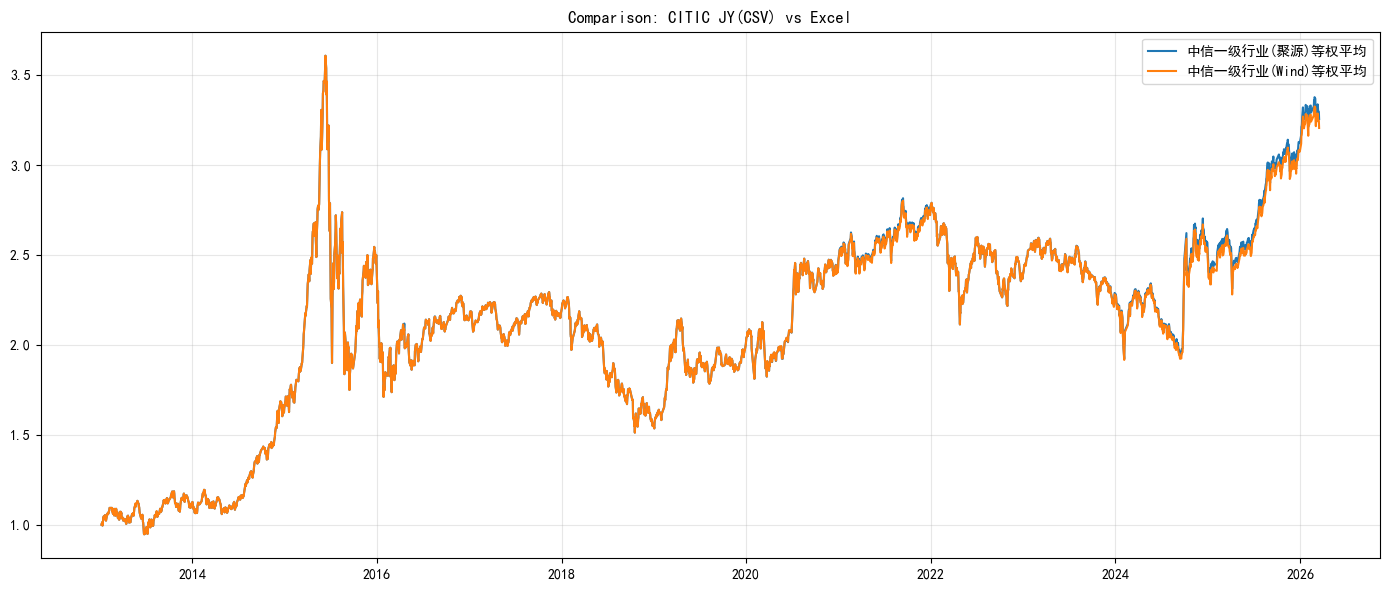

Saved: results/nav_comparison_multi_sources\comparison_two_yjhy.png


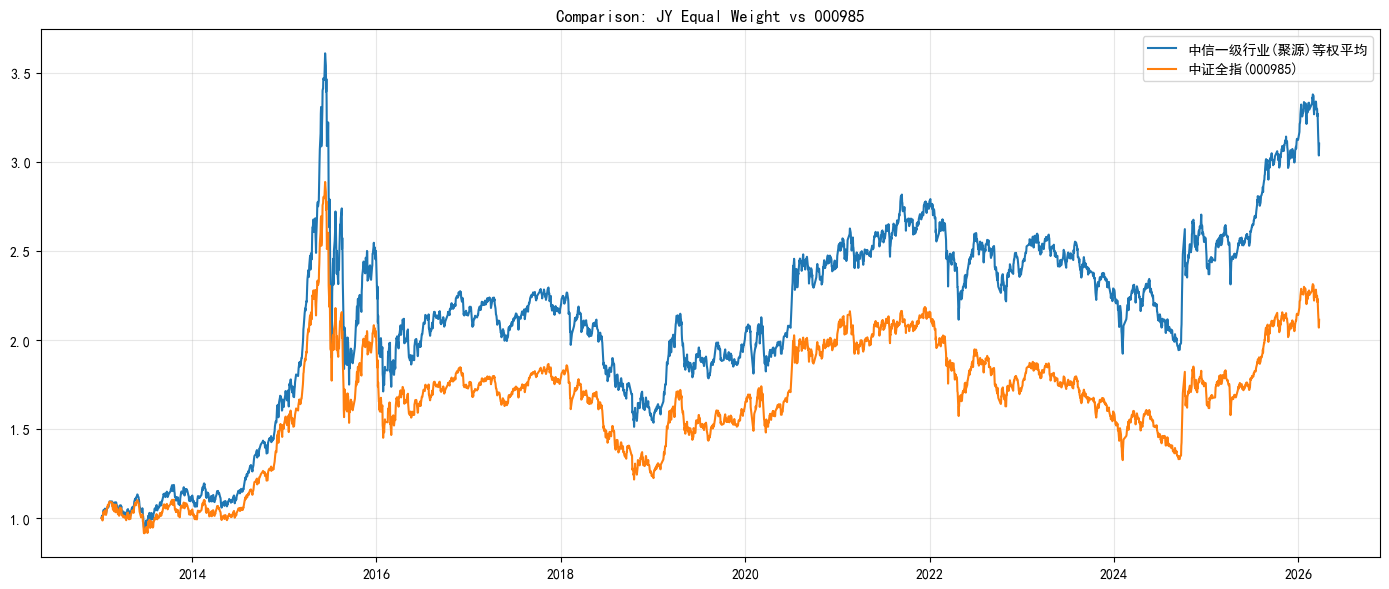

Saved: results/nav_comparison_multi_sources\comparison_jy_vs_000985.png


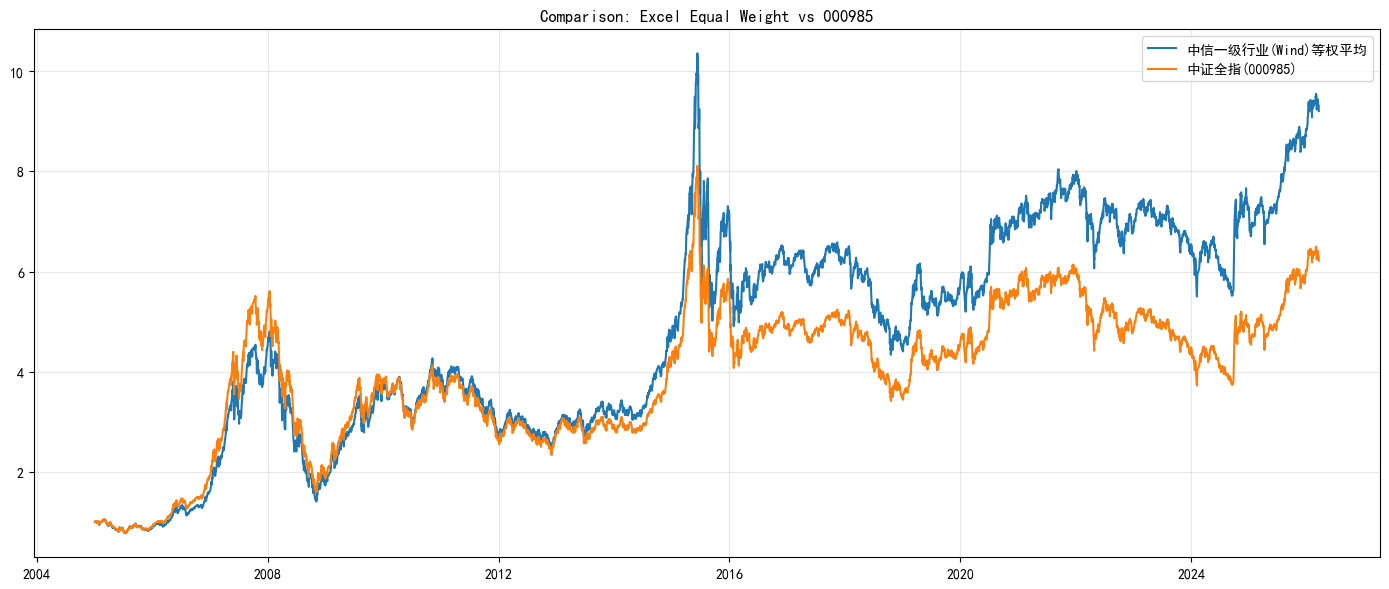

Saved: results/nav_comparison_multi_sources\comparison_xlsx_vs_000985.png


In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from core.NavAnalyzer import Visualizer, PerformanceReport

def compare_multiple_yjhy_sources():
    # 1. 加载中证全指 (000985)
    csi_path = r"D:\DATA\INDEX\STOCK\000985.CSI.xlsx"
    df_csi = pd.read_excel(csi_path, header=5)
    df_csi['Date'] = pd.to_datetime(df_csi['Date'])
    df_csi = df_csi.set_index('Date').sort_index()
    csi_nav = df_csi['close']
    csi_nav.name = "中证全指(000985)"

    # 2. 加载中信一级行业 (聚源价格版 yjhy_prices.csv)
    yjhy_prices_path = r"D:\DATA\INDEX\ZX\yjhy_prices.csv"
    try:
        df_prices = pd.read_csv(yjhy_prices_path, encoding='utf-8')
    except:
        df_prices = pd.read_csv(yjhy_prices_path, encoding='utf-8-sig')
    df_prices['TradingDay'] = pd.to_datetime(df_prices['TradingDay'])
    df_prices = df_prices.set_index('TradingDay').sort_index().apply(pd.to_numeric, errors='coerce')
    ret_prices = df_prices.pct_change().dropna().mean(axis=1)
    nav_prices = (1 + ret_prices).cumprod()
    nav_prices.name = "中信一级行业(聚源)等权平均"

    # 3. 加载中信一级行业 (Excel版 ZX_YJHY.xlsx)
    xlsx_path = r"D:\DATA\INDEX\ZX\ZX_YJHY.xlsx"
    # 跳过前几行元数据逻辑 (参考之前的 Cell 13)
    df_xlsx = pd.read_excel(xlsx_path, skiprows=10)
    df_xlsx.iloc[:, 0] = pd.to_datetime(df_xlsx.iloc[:, 0], errors='coerce')
    df_xlsx = df_xlsx.dropna(subset=[df_xlsx.columns[0]])
    df_xlsx = df_xlsx.set_index(df_xlsx.columns[0]).sort_index().apply(pd.to_numeric, errors='coerce')
    ret_xlsx = df_xlsx.pct_change().dropna().mean(axis=1)
    nav_xlsx = (1 + ret_xlsx).cumprod()
    nav_xlsx.name = "中信一级行业(Wind)等权平均"

    # 4. 对齐日期与归一化逻辑封装
    def get_aligned_norm_dict(series_list):
        common_idx = series_list[0].index
        for s in series_list[1:]:
            common_idx = common_idx.intersection(s.index)
        
        result_dict = {}
        for s in series_list:
            aligned = s.loc[common_idx]
            norm = aligned / aligned.iloc[0]
            result_dict[s.name] = norm
        return result_dict

    output_dir = "results/nav_comparison_multi_sources"
    os.makedirs(output_dir, exist_ok=True)

    # 绘图逻辑：由于 compare_multiple_navs 内部写死了文件名 comparison_nav.png
    # 我们使用 plt 直接绘制并保存，或者手动调用 plt.savefig
    
    def plot_custom(nav_dict, title, filename):
        plt.figure(figsize=(14, 6))
        for name, nav_ser in nav_dict.items():
            plt.plot(pd.to_datetime(nav_ser.index), nav_ser.values, label=name)
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_path = os.path.join(output_dir, filename)
        plt.savefig(save_path, dpi=150)
        plt.show()
        print(f"Saved: {save_path}")

    # 图片 1: 两个等权平均对比
    dict1 = get_aligned_norm_dict([nav_prices, nav_xlsx])
    plot_custom(dict1, "Comparison: CITIC JY(CSV) vs Excel", "comparison_two_yjhy.png")

    # 图片 2: 聚源等权平均 vs 000985
    dict2 = get_aligned_norm_dict([nav_prices, csi_nav])
    plot_custom(dict2, "Comparison: JY Equal Weight vs 000985", "comparison_jy_vs_000985.png")

    # 图片 3: Excel等权平均 vs 000985
    dict3 = get_aligned_norm_dict([nav_xlsx, csi_nav])
    plot_custom(dict3, "Comparison: Excel Equal Weight vs 000985", "comparison_xlsx_vs_000985.png")

if __name__ == "__main__":
    compare_multiple_yjhy_sources()
